In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import xarray as xr
import json
from matplotlib import pyplot as plt
from pympler import asizeof

import glm_fit_tools as gft

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
session_name = 'multiplane-ophys_721291_2024-05-16_08-57-00'
data_type = 'filtered_events'
dm_version = 0

X, response, response_info, run_params, unstd_features, use_indices = \
    gft.load_data(session_name, data_type, dm_version)

X_trim = X[use_indices, :]
response_trim = response[use_indices, :]
ophys_frame_rate = response_info['ophys_frame_rate']

In [6]:
fit_params = gft.default_fit_params()

In [9]:
stratified_list = gft.set_stratified_list(fit_params, X, unstd_features, use_indices, ophys_frame_rate)
stratified_frames, cv_inds_stratified = gft.get_stratified_folds(fit_params, stratified_list)

In [14]:
X_trim = X[use_indices, :]
response_trim = response[use_indices, :]
lambdas_cv, W_cv, var_ratio_train_cv, var_ratio_test_cv, vr_test_train_ratio_cv =\
    gft.collect_session_results(run_params, fit_params, X_trim, response_trim, stratified_frames, cv_inds_stratified)

In [22]:
var_ratio_mean_model = gft.get_full_session_var_ratio_from_mean_model(W_cv, X_trim, response_trim)

In [34]:
gft.save_glm_restuls(dm_version, session_name, data_type, 
                     fit_params,  use_indices, stratified_frames, cv_inds_stratified,
                     lambdas_cv, W_cv,
                     var_ratio_train_cv, var_ratio_test_cv,
                     vr_test_train_ratio_cv, var_ratio_mean_model)

# Loading

In [37]:
save_dir_base = Path('/root/capsule/scratch')
# folder_name = f'glm_results_v{dm_version:02}_{session_name}_{data_type}'
# save_dir = save_dir_base / folder_name
save_dir = save_dir_base
save_fn = save_dir / f'glm_results_v{dm_version:02}_{session_name}_{data_type}.npy'

In [38]:
results = np.load(save_fn, allow_pickle=True).item()

# getting full session traces

In [40]:
session_model_from_splits, session_model_from_mean_W = \
    gft.get_sessionwise_model_traces(results['fit_params'],
                                     results['W_cv'],
                                     X[results['use_indices'],:],
                                     response[results['use_indices'],:],
                                     results['stratified_frames'],
                                     results['cv_inds_stratified'])

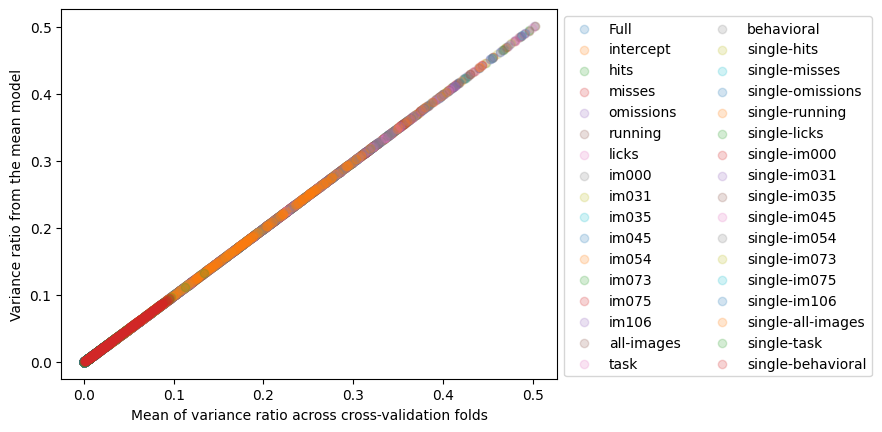

In [43]:
mean_var_ratio = var_ratio_train_cv.mean(dim='test_fold_ind')
fig, ax = plt.subplots()
for model in var_ratio_mean_model.model.values:
    ax.scatter(mean_var_ratio.sel(model=model), var_ratio_mean_model.sel(model=model), label=model, alpha=0.2)
ax.set_xlabel('Mean of variance ratio across cross-validation folds')
ax.set_ylabel('Variance ratio from the mean model')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=2)

Text(0, 0.5, 'Variance ratio from the mean model')

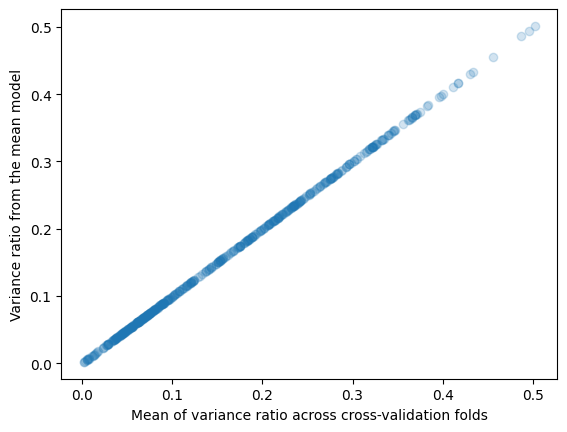

In [44]:
mean_var_ratio = var_ratio_train_cv.mean(dim='test_fold_ind')
fig, ax = plt.subplots()
model='Full'
ax.scatter(mean_var_ratio.sel(model=model), var_ratio_mean_model.sel(model=model), label=model, alpha=0.2)
ax.set_xlabel('Mean of variance ratio across cross-validation folds')
ax.set_ylabel('Variance ratio from the mean model')


In [45]:
(mean_var_ratio - var_ratio_mean_model).std()
# they are not the same, but they are very similar

<xarray.DataArray ()> Size: 8B
array(0.0003378)

Text(0, 0.5, 'Cumulative fraction of cells')

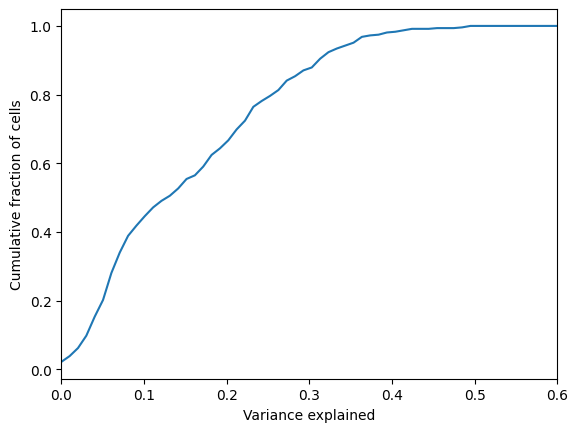

In [50]:
fig, ax = plt.subplots()
model='Full'
var_ratio = mean_var_ratio.sel(model=model)
bins = np.linspace(0, 1, 100)
hist = np.histogram(var_ratio, bins=bins)[0]
cum_hist = np.cumsum(hist) / hist.sum()
ax.plot(bins[:-1], cum_hist)
ax.set_xlim(0, 0.6)
ax.set_xlabel('Variance explained')
ax.set_ylabel('Cumulative fraction of cells')

In [55]:
sorted_inds = np.argsort(-mean_var_ratio.sel(model='Full').values)

In [58]:
ci = 0
model_from_split = session_model_from_splits.sel(model='Full').isel(cell_roi_id=sorted_inds[ci])
model_from_mean = session_model_from_mean_W.sel(model='Full').isel(cell_roi_id=sorted_inds[ci])

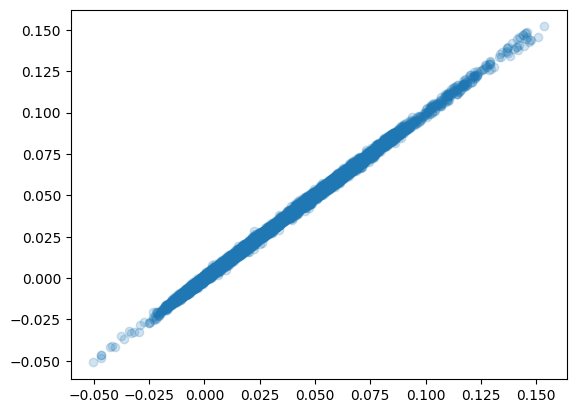

In [59]:
fig, ax = plt.subplots()
ax.scatter(model_from_mean, model_from_split, alpha=0.2)

(1023.5729, 1223.5729000000001)

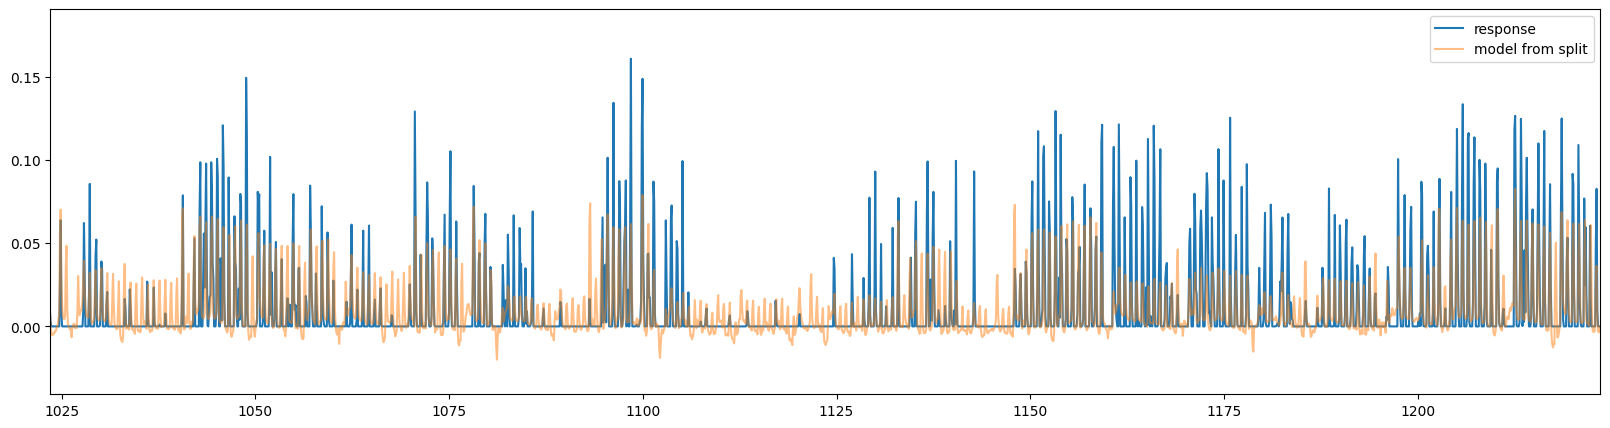

In [70]:
ci = 1
model_from_split = session_model_from_splits.sel(model='Full').isel(cell_roi_id=sorted_inds[ci])
model_from_mean = session_model_from_mean_W.sel(model='Full').isel(cell_roi_id=sorted_inds[ci])
response = response_trim.isel(cell_roi_id=sorted_inds[ci])
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(response.timestamps, response, label='response')
ax.plot(response.timestamps, model_from_split, label='model from split', alpha=0.5)
ax.legend()

start = response.timestamps[0]+700
dur = 200
ax.set_xlim(start, start + dur)
